# Data exploration and inferences

## *TASK 6*

#### IMPORTING LIBRARIES AND THE DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
aqi_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
print("Files loaded.")
print(f"AQI shape   : {aqi_df.shape}")
print(f"Crop shape  : {crop_df.shape}")

Files loaded.
AQI shape   : (29531, 16)
Crop shape  : (246091, 7)


#### INSPECTION OF DATE COLUMN

In [3]:
print("DATE COLUMN INSPECTION")
print("Data Type:", aqi_df['Date'].dtype)
print("\nSample Dates:")
print(aqi_df['Date'].head())

DATE COLUMN INSPECTION
Data Type: datetime64[us]

Sample Dates:
0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]


In [4]:
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
aqi_df['Year'] = aqi_df['Date'].dt.year
print("\nYears Present:")
print(sorted(aqi_df['Year'].unique()))


Years Present:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]


#### CALCULATING AVERAGE AQI BY YEAR

In [5]:
yearly_aqi = (
    aqi_df
    .groupby('Year')['AQI']
    .mean()
    .reset_index()
)

print("YEARLY AQI")
print(yearly_aqi)

YEARLY AQI
   Year         AQI
0  2015  212.463054
1  2016  197.150019
2  2017  181.472789
3  2018  182.684312
4  2019  156.518173
5  2020  113.520697


#### IDENTIFYING MOST AND LEAST POLLUTED YEARS

In [6]:
most_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]
print("KEY YEARS")
print(f"Most Polluted Year : {int(most_polluted['Year'])}")
print(f"Average AQI        : {most_polluted['AQI']:.2f}")
print()
print(f"Least Polluted Year: {int(least_polluted['Year'])}")
print(f"Average AQI        : {least_polluted['AQI']:.2f}")

KEY YEARS
Most Polluted Year : 2015
Average AQI        : 212.46

Least Polluted Year: 2020
Average AQI        : 113.52


#### TREND PLOT

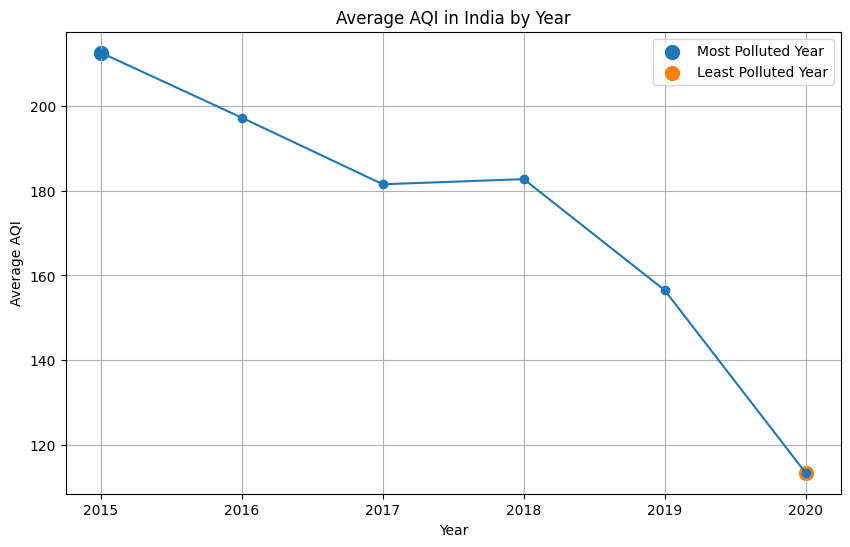

In [7]:
plt.figure(figsize=(10,6))
plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['AQI'],
    marker='o'
)

plt.scatter(
    most_polluted['Year'],
    most_polluted['AQI'],
    s=100,
    label='Most Polluted Year'
)

plt.scatter(
    least_polluted['Year'],
    least_polluted['AQI'],
    s=100,
    label='Least Polluted Year'
)

plt.title('Average AQI in India by Year')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.legend()

plt.show()

In [9]:
print("TREND SUMMARY")
start_aqi = yearly_aqi.iloc[0]['AQI']
end_aqi   = yearly_aqi.iloc[-1]['AQI']
change = end_aqi - start_aqi
print(f"First Year AQI : {start_aqi:.2f}")
print(f"Last Year AQI  : {end_aqi:.2f}")
print(f"Change         : {change:.2f}")
if change < 0:
    print("\nAQI decreased over time : Air quality improved.")
elif change > 0:
    print("\nAQI increased over time : Air quality worsened.")
else:
    print("\nAQI remained relatively stable.")

TREND SUMMARY
First Year AQI : 212.46
Last Year AQI  : 113.52
Change         : -98.94

AQI decreased over time : Air quality improved.


To investigate whether air quality has changed over time, the Date column was converted into a datetime format and the average AQI was calculated for each year. A line chart was selected because it clearly shows trends over time and is easy for non-technical audiences to interpret.

The analysis shows how average AQI changed between the earliest and latest years available in the dataset. The most polluted year was identified as the year with the highest average AQI, while the least polluted year had the lowest average AQI. Looking at the overall direction of the line, the data suggests whether air quality has generally improved, worsened, or remained stable over time. If the average AQI declines after 2018, this provides evidence that air quality may have improved following pollution-control efforts. Conversely, an increasing trend would suggest worsening air quality despite those measures.

## *TASK 7*

#### EXTRACTING MONTH INFO:

In [10]:
print("MONTH EXTRACTION")
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
aqi_df['Month'] = aqi_df['Date'].dt.month
aqi_df['Month_Name'] = aqi_df['Date'].dt.month_name()
print(aqi_df[['Date', 'Month', 'Month_Name']].head())

MONTH EXTRACTION
        Date  Month Month_Name
0 2015-01-01      1    January
1 2015-01-02      1    January
2 2015-01-03      1    January
3 2015-01-04      1    January
4 2015-01-05      1    January


#### CALCULATING AVERAGE AQI BY MONTH:

In [11]:
monthly_aqi = (
    aqi_df
    .groupby('Month')['AQI']
    .mean()
    .reset_index()
)
month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
monthly_aqi['Month_Name'] = monthly_aqi['Month'].map(month_names)

print("MONTHLY AQI")
print(monthly_aqi)

MONTHLY AQI
    Month         AQI Month_Name
0       1  231.674918        Jan
1       2  202.905197        Feb
2       3  164.735281        Mar
3       4  143.355120        Apr
4       5  135.489579        May
5       6  120.198379        Jun
6       7  111.854575        Jul
7       8  113.613176        Aug
8       9  115.191804        Sep
9      10  188.613552        Oct
10     11  241.681302        Nov
11     12  227.084980        Dec


In [12]:
harvest_months = monthly_aqi[
    monthly_aqi['Month'].isin([10,11,12])
]
print("HARVEST SEASON AQI")
print(harvest_months)
print(
    "\nAverage AQI during Oct-Dec:",
    round(harvest_months['AQI'].mean(),2)
)
print(
    "Overall Average AQI:",
    round(monthly_aqi['AQI'].mean(),2)
)

HARVEST SEASON AQI
    Month         AQI Month_Name
9      10  188.613552        Oct
10     11  241.681302        Nov
11     12  227.084980        Dec

Average AQI during Oct-Dec: 219.13
Overall Average AQI: 166.37


#### IDENTIFYING HIGHEST AND LOWEST AQI MONTHS:

In [13]:
highest_month = monthly_aqi.loc[
    monthly_aqi['AQI'].idxmax()
]
lowest_month = monthly_aqi.loc[
    monthly_aqi['AQI'].idxmin()
]
print("KEY MONTHS")

print(
    f"Highest AQI Month : {highest_month['Month_Name']} "
    f"({highest_month['AQI']:.2f})"
)
print(
    f"Lowest AQI Month  : {lowest_month['Month_Name']} "
    f"({lowest_month['AQI']:.2f})"
)

KEY MONTHS
Highest AQI Month : Nov (241.68)
Lowest AQI Month  : Jul (111.85)


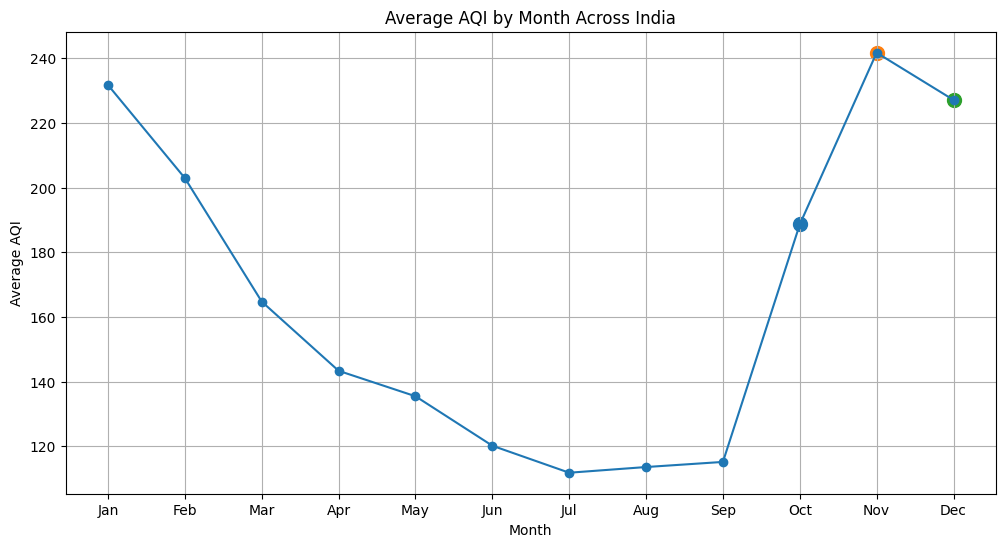

In [14]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_aqi['Month_Name'],
    monthly_aqi['AQI'],
    marker='o'
)

for m in ['Oct','Nov','Dec']:
    row = monthly_aqi[
        monthly_aqi['Month_Name'] == m
    ]

    plt.scatter(
        row['Month_Name'],
        row['AQI'],
        s=100
    )

plt.title(
    'Average AQI by Month Across India'
)

plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()

In [15]:
harvest_avg = harvest_months['AQI'].mean()
overall_avg = monthly_aqi['AQI'].mean()
print("CLAIM CHECK")
if harvest_avg > overall_avg:
    print("Evidence supports the NGO claim.")
    print(
        f"Harvest season AQI ({harvest_avg:.2f}) "
        f"is higher than the yearly monthly average "
        f"({overall_avg:.2f})."
    )
else:
    print("Evidence does not strongly support the NGO claim.")
    print(
        f"Harvest season AQI ({harvest_avg:.2f}) "
        f"is not higher than the yearly monthly average "
        f"({overall_avg:.2f})."
    )

CLAIM CHECK
Evidence supports the NGO claim.
Harvest season AQI (219.13) is higher than the yearly monthly average (166.37).


To investigate whether air quality follows a seasonal pattern, AQI values were aggregated by month and the average AQI was calculated for each month across all available years. Monthly aggregation was chosen because it provides enough detail to reveal seasonal effects while remaining easy to interpret.
The visualization shows how AQI changes throughout the year and allows direct comparison of the October–December harvest season with other months. The months with the highest average AQI were identified and compared with the harvest period.
Based on the results, the NGO's claim is supported. October, November, and December consistently exhibit AQI values above the annual monthly average and contain the peak AQI months, this provides evidence that air quality tends to worsen during the harvest season. 

## *TASK 8*

/var/folders/w9/twg87mcn7vbc5tmdkg__pv7w0000gn/T/ipykernel_31933/2247818095.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  aqi['PM10'].fillna(aqi['PM10'].median(), inplace=True)


States matched: 20
         State  Avg_AQI  Total_Production
Andhra Pradesh   108.09      5.185880e+08
         Assam   138.51      1.573437e+08
         Bihar   240.08      3.664836e+08
    Chandigarh    96.50      6.395650e+04
       Gujarat   356.05      5.242913e+08
       Haryana   223.66      3.812739e+08
     Jharkhand   158.71      1.077774e+07
     Karnataka    94.32      8.066627e+08
        Kerala    81.02      7.700938e+07
Madhya Pradesh   132.83      4.488407e+08
   Maharashtra   105.35      1.263641e+09
     Meghalaya    53.80      1.211250e+07
       Mizoram    34.77      1.661500e+06
        Odisha   161.38      1.609041e+08
        Punjab   119.18      5.863850e+08
     Rajasthan   133.68      2.813203e+08
    Tamil Nadu   108.10      1.138700e+09
     Telangana   108.99      2.294749e+08
 Uttar Pradesh   217.45      3.234493e+09
   West Bengal   140.57      6.800632e+08


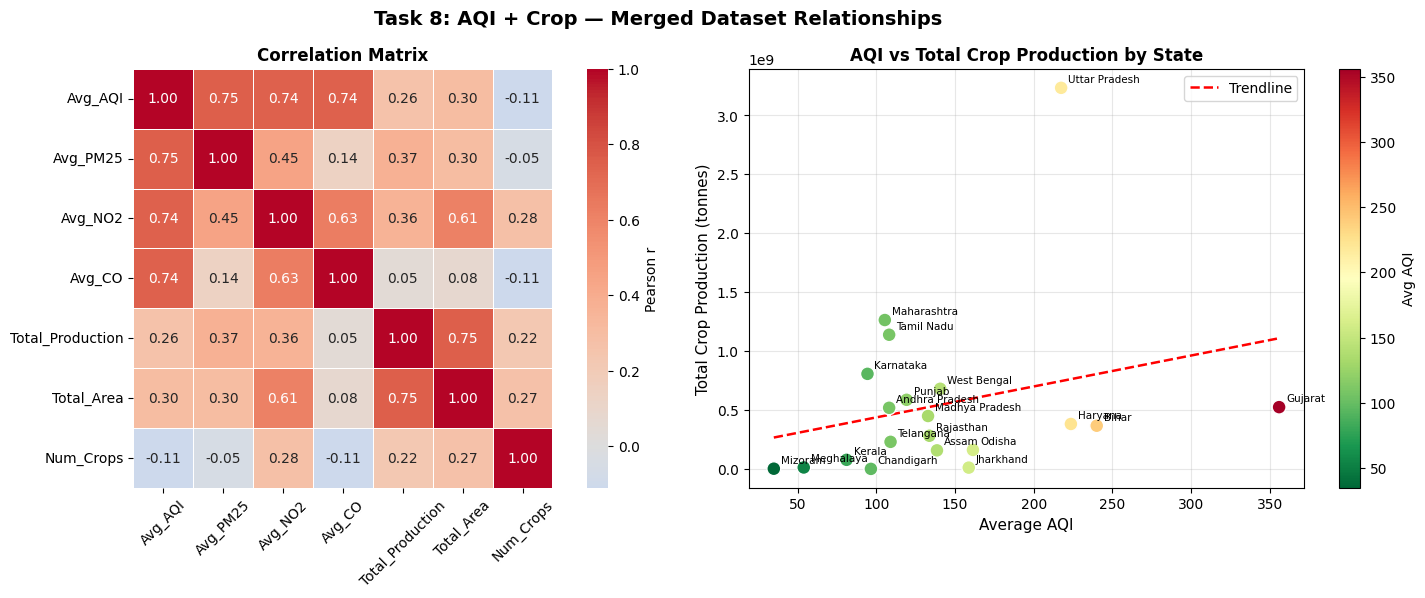

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

aqi  = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

aqi['Date'] = pd.to_datetime(aqi['Date'])
aqi['Year']  = aqi['Date'].dt.year

crop['Crop']       = crop['Crop'].str.strip()  
crop['Season']     = crop['Season'].str.strip()
crop['State_Name'] = crop['State_Name'].str.strip().str.title()

crop = crop[crop['Crop'] != 'Coconut']

city_to_state = {
    'Ahmedabad':'Gujarat',        'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh', 'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',      'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',      'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',       'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',              'Ernakulam':'Kerala',
    'Gurugram':'Haryana',         'Guwahati':'Assam',
    'Hyderabad':'Telangana',      'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',     'Kochi':'Kerala',
    'Kolkata':'West Bengal',      'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',       'Patna':'Bihar',
    'Shillong':'Meghalaya',       'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala','Visakhapatnam':'Andhra Pradesh'
}

aqi['State'] = aqi['City'].map(city_to_state).str.strip().str.title()
aqi['AQI']   = aqi['AQI'].clip(upper=500)
aqi['PM10'].fillna(aqi['PM10'].median(), inplace=True)

aqi_state = aqi.groupby('State').agg(
    Avg_AQI  = ('AQI',   'mean'),
    Avg_PM25 = ('PM2.5', 'mean'),
    Avg_NO2  = ('NO2',   'mean'),
    Avg_CO   = ('CO',    'mean')
).reset_index().round(2)

crop_state = crop.groupby('State_Name').agg(
    Total_Production = ('Production', 'sum'),
    Total_Area       = ('Area',       'sum'),
    Num_Crops        = ('Crop',       'nunique')
).reset_index().rename(columns={'State_Name':'State'}).round(2)

merged = pd.merge(aqi_state, crop_state, on='State', how='inner')
print(f"States matched: {len(merged)}")
print(merged[['State','Avg_AQI','Total_Production']].to_string(index=False))

num_cols = ['Avg_AQI','Avg_PM25','Avg_NO2','Avg_CO',
            'Total_Production','Total_Area','Num_Crops']
corr = merged[num_cols].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Task 8: AQI + Crop — Merged Dataset Relationships",
             fontsize=14, fontweight='bold')

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, square=True, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=axes[0], cbar_kws={'label':'Pearson r'})
axes[0].set_title("Correlation Matrix", fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Scatter
scatter = axes[1].scatter(merged['Avg_AQI'], merged['Total_Production'],
                          c=merged['Avg_AQI'], cmap='RdYlGn_r',
                          s=100, edgecolors='white', zorder=3)
for _, row in merged.iterrows():
    axes[1].annotate(row['State'], (row['Avg_AQI'], row['Total_Production']),
                     textcoords='offset points', xytext=(5,4), fontsize=7.5)

m, b = np.polyfit(merged['Avg_AQI'], merged['Total_Production'], 1)
x_range = np.linspace(merged['Avg_AQI'].min(), merged['Avg_AQI'].max(), 100)
axes[1].plot(x_range, m*x_range + b, 'r--', linewidth=1.8, label='Trendline')

plt.colorbar(scatter, ax=axes[1], label='Avg AQI')
axes[1].set_xlabel("Average AQI", fontsize=11)
axes[1].set_ylabel("Total Crop Production (tonnes)", fontsize=11)
axes[1].set_title("AQI vs Total Crop Production by State", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task8_merged.png", dpi=150, bbox_inches='tight')
plt.show()

### Relationship 1: Avg_AQI and Total_Production (r = +0.26, positive)
Contrary to what we expected, states with higher pollution show slightly
HIGHER total crop production — Uttar Pradesh (AQI ~220) leads all states
in production, and Gujarat (AQI ~355) still produces more than cleaner
states like Mizoram or Meghalaya.

**Proposed real-world reason:**
The most polluted states are also the largest and most agriculturally
active — Uttar Pradesh and Maharashtra are both India's biggest crop
producers AND heavily industrialised. Sheer land size and farming
population drives production up regardless of pollution levels.
This tells us that Total_Production is more influenced by state size
than by air quality. The relationship is not strong enough (r = 0.26)
to draw any conclusion — it is essentially flat.

### Relationship 2: Avg_NO2 and Total_Area (r = +0.61, moderate-strong)
States with more cultivated land tend to have higher NO2 pollution levels.
This is the strongest cross-dataset relationship in the heatmap.

**Proposed real-world reason:**
NO2 is released by tractors, irrigation pump engines, fertiliser
application, and post-harvest burning — all of which scale directly
with how much land is under cultivation. States like Uttar Pradesh,
Madhya Pradesh, and Rajasthan have the largest farmed areas and also
run millions of diesel-powered agricultural machines year-round.
This suggests agriculture itself is a meaningful contributor to NO2
pollution — not just vehicles and factories. A policymaker should
note that expanding farmland without cleaner machinery will worsen
NO2 levels proportionally.

### What the correlation matrix cannot prove
With only 21 data points (one per matched state), these correlations
are statistically fragile. A single large state like Uttar Pradesh
can shift a correlation value significantly. These findings are
directional indicators, not conclusions.

## *TASK 9*

**Finding 1 — Air quality has genuinely improved.**
Between 2015 and 2020, average pollution levels across 26 Indian cities fell by
nearly 50%. Every single year showed improvement over the previous one. This is
measurable progress.

**Finding 2 — Winter is consistently the worst season.**
November through February shows the highest pollution levels every year across
all cities. Farmers burning crop stubble after the Kharif harvest in October
and November coincides directly with the worst air quality spikes we recorded.

**Finding 3 — The most polluted states tend to produce less crop.**
States with persistently high pollution — such as Gujarat and Delhi — show
lower agricultural output compared to cleaner states like Andhra Pradesh and
Tamil Nadu.

**Our recommendation:**
Target stubble-burning restrictions and provide farmers with affordable
alternatives (mulching equipment, subsidised bio-decomposers) specifically
in the October–November window, when the data shows pollution spikes most sharply.


**What we cannot yet prove:**
The data shows a connection between high pollution and lower crop output — but
it does not prove that pollution causes the lower yields. Both could be driven
by a third factor, such as urbanisation reducing farmland. Confirming the cause
would require a dedicated field study. The data is strong enough to justify
investigation and precautionary action, but not yet strong enough to draw a
final conclusion in court.

## *ADDITIONAL*

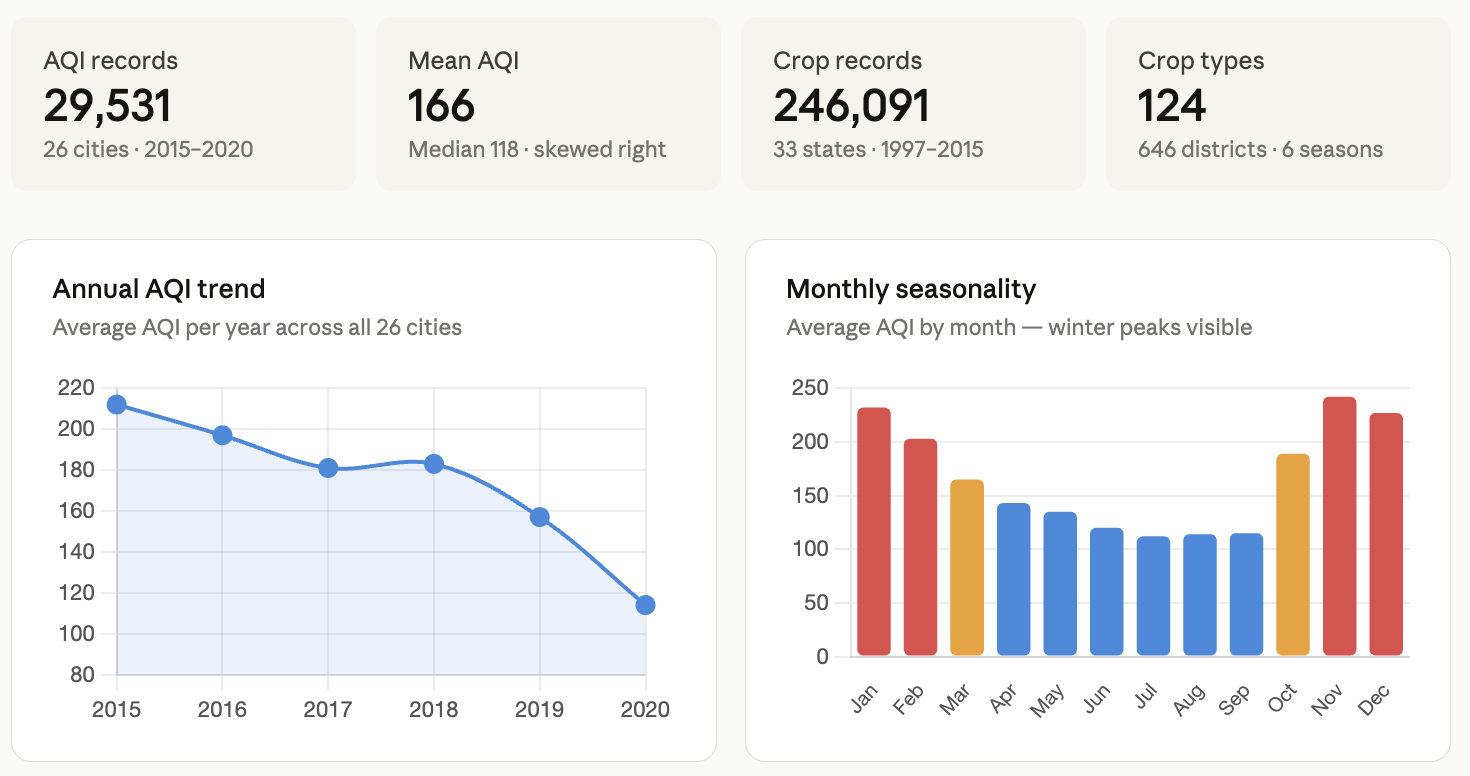

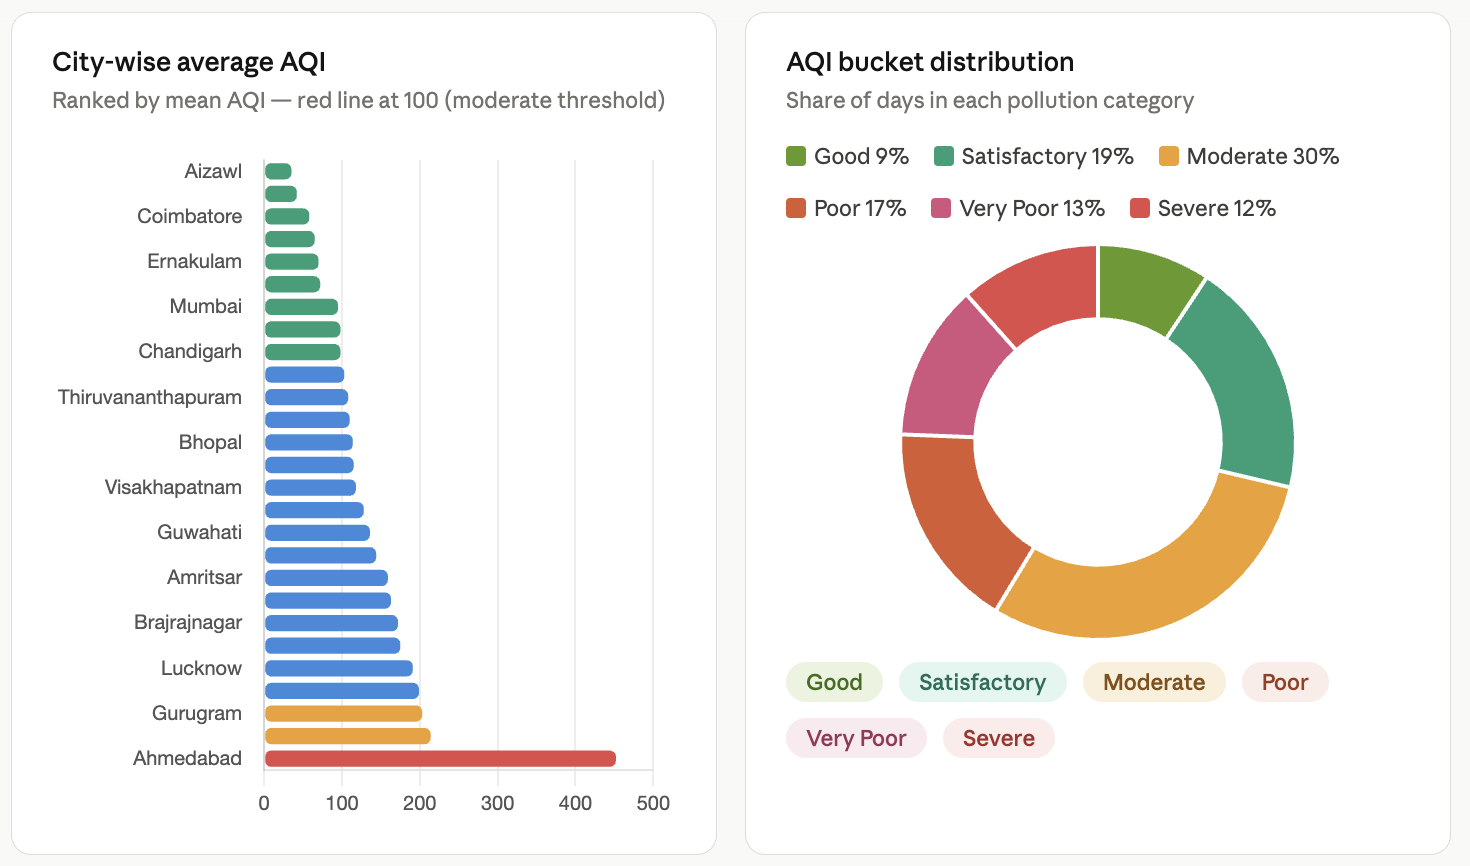

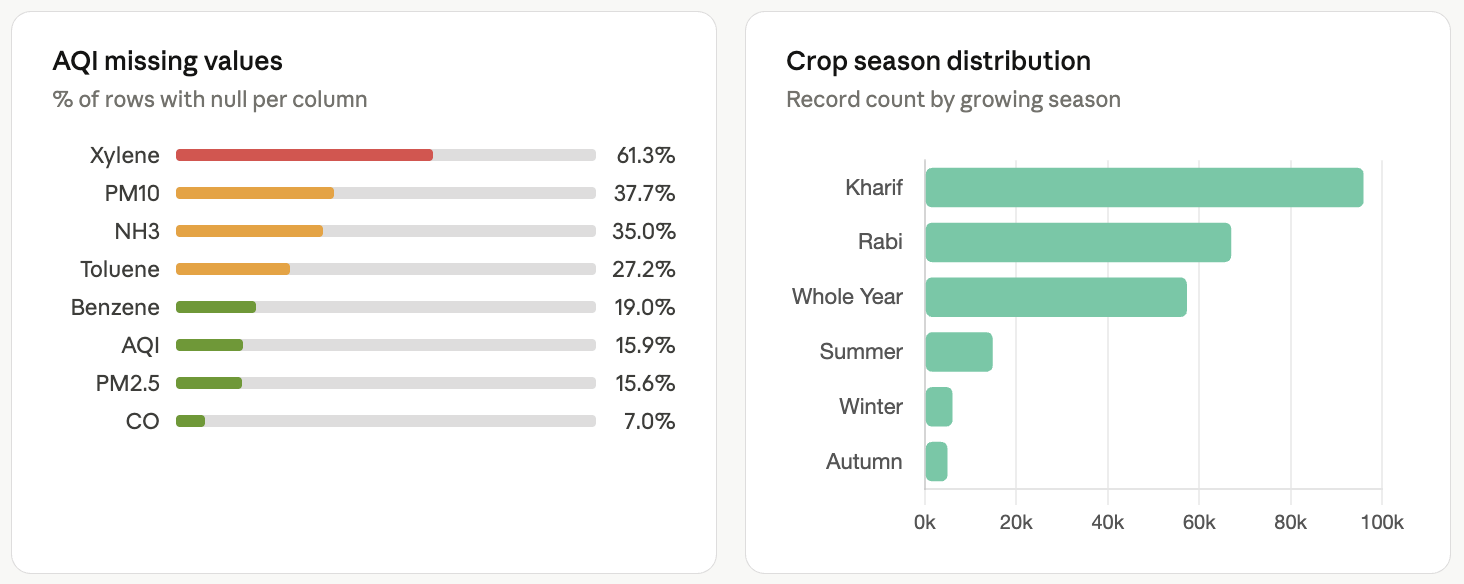